In [7]:
!pip install -U scikit-learn

   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
    --------------------------------------- 0.2/8.3 MB 5.3 MB/s eta 0:00:02
   ------ --------------------------------- 1.2/8.3 MB 15.9 MB/s eta 0:00:01
   ------------------------- -------------- 5.3/8.3 MB 42.6 MB/s eta 0:00:01
   ------------------------------------ --- 7.5/8.3 MB 43.4 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 40.7 MB/s eta 0:00:00
   ---------------------------------------- 0.0/474.0 kB ? eta -:--:--
   --------------------------------------- 474.0/474.0 kB 29.0 MB/s eta 0:00:00
  Attempting uninstall: threadpoolctl
    Found existing installation: threadpoolctl 2.2.0
    Uninstalling threadpoolctl-2.2.0:
      Successfully uninstalled threadpoolctl-2.2.0
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.4.2
    Uninstalling scikit-learn-1.4.2:
      Successfully uninstalled scikit-learn-1.4.2


In [11]:
import copy
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_covtype
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

np.random.seed(42)

In [15]:
from sklearn.datasets import fetch_covtype

print("fetch_covtype imported successfully!")

fetch_covtype imported successfully!


In [21]:
!pip install -q ucimlrepo

In [23]:
from ucimlrepo import fetch_ucirepo

print("Downloading Covertype dataset...")

covertype = fetch_ucirepo(id=31)

X = covertype.data.features.values.astype("float32")
y = covertype.data.targets.values.ravel().astype("int64")

print("Dataset loaded successfully!")
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Classes:", sorted(set(y)))

Dataset loaded successfully!
X shape: (581012, 54)
y shape: (581012,)
Classes: [1, 2, 3, 4, 5, 6, 7]


In [25]:
class_labels = np.unique(y)
class_counts = np.bincount(y)[1:]  # labels are 1..7

class_names = [
    "Spruce/Fir",
    "Lodgepole Pine",
    "Ponderosa Pine",
    "Cottonwood/Willow",
    "Aspen",
    "Douglas-fir",
    "Krummholz"
]

distribution = pd.DataFrame({
    "Class": np.arange(1, 8),
    "Name": class_names,
    "Count": class_counts,
    "Percentage": class_counts / len(y) * 100
})

display(distribution)

imbalance_ratio = class_counts.max() / class_counts.min()
print(f"Imbalance ratio (largest/smallest): {imbalance_ratio:.2f}:1")

,Class,Name,Count,Percentage
0,1,Spruce/Fir,211840,36.460521
1,2,Lodgepole Pine,283301,48.759922
2,3,Ponderosa Pine,35754,6.153746
3,4,Cottonwood/Willow,2747,0.472796
4,5,Aspen,9493,1.633873
5,6,Douglas-fir,17367,2.989095
6,7,Krummholz,20510,3.530048


Imbalance ratio (largest/smallest): 103.13:1


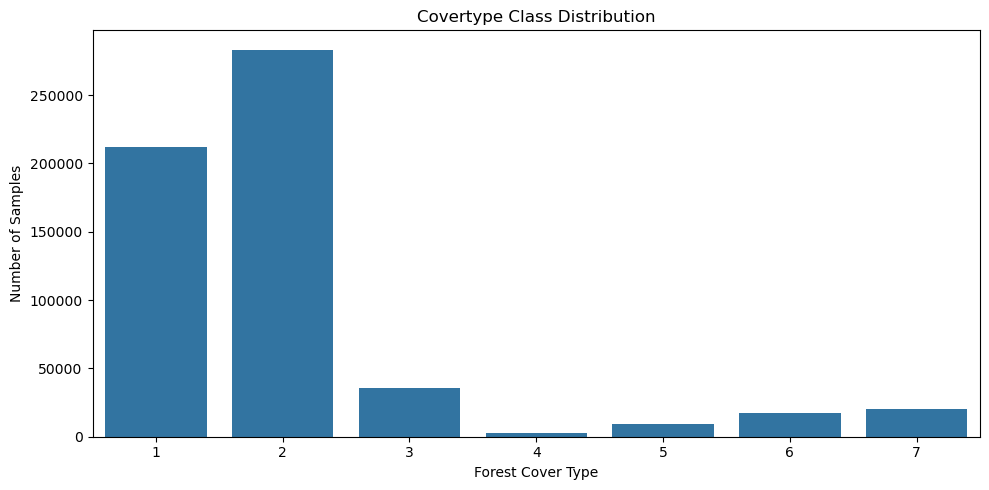

In [27]:
plt.figure(figsize=(10, 5))
sns.barplot(data=distribution, x="Class", y="Count")
plt.title("Covertype Class Distribution")
plt.xlabel("Forest Cover Type")
plt.ylabel("Number of Samples")
plt.tight_layout()
plt.show()

In [29]:
# Convert labels 1..7 to 0..6
y_zero = y - 1

# One-hot encode the target: N x 7
K = 7
Y_onehot = np.eye(K, dtype=np.float32)[y_zero]

print("Zero-indexed labels:", np.unique(y_zero))
print("One-hot target shape:", Y_onehot.shape)
print("Example:", Y_onehot[0])


Zero-indexed labels: [0 1 2 3 4 5 6]
One-hot target shape: (581012, 7)
Example: [0. 0. 0. 0. 1. 0. 0.]


In [31]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_zero,
    test_size=0.20,
    stratify=y_zero,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("Training set:", X_train.shape, y_train.shape)
print("Validation set:", X_val.shape, y_val.shape)
print("Testing set:", X_test.shape, y_test.shape)

print("\nPercentages:")
print("Train:", len(y_train)/len(y)*100)
print("Validation:", len(y_val)/len(y)*100)
print("Test:", len(y_test)/len(y)*100)

Training set: (464809, 54) (464809,)
Validation set: (58101, 54) (58101,)
Testing set: (58102, 54) (58102,)

Percentages:
Train: 79.99989673190915
Validation: 9.999965577303051
Test: 10.000137690787799


In [33]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train).astype(np.float32)
X_val = scaler.transform(X_val).astype(np.float32)
X_test = scaler.transform(X_test).astype(np.float32)

print("Training feature mean (first 5):", X_train.mean(axis=0)[:5])
print("Training feature std  (first 5):", X_train.std(axis=0)[:5])

Training feature mean (first 5): [-1.8026466e-08 -2.5448384e-07 -5.5451764e-08 -2.6393087e-07
 -2.0168498e-08]
Training feature std  (first 5): [0.99988407 0.99983937 1.0005753  0.999666   0.99981916]


In [35]:
train_class_counts = np.bincount(y_train, minlength=K)
N_train = len(y_train)

class_weights = N_train / (K * train_class_counts)

weights_table = pd.DataFrame({
    "Class": np.arange(1, K + 1),
    "Name": class_names,
    "Training Count": train_class_counts,
    "Class Weight": class_weights
})

display(weights_table)

,Class,Name,Training Count,Class Weight
0,1,Spruce/Fir,169472,0.391813
1,2,Lodgepole Pine,226640,0.292981
2,3,Ponderosa Pine,28603,2.321480
3,4,Cottonwood/Willow,2198,30.209866
4,5,Aspen,7594,8.743914
5,6,Douglas-fir,13894,4.779134
6,7,Krummholz,16408,4.046885


In [43]:
class DFNN:
    def __init__(self, layer_sizes, seed=42):
        self.layer_sizes = layer_sizes
        self.rng = np.random.default_rng(seed)
        self.params = {}

        # He initialization for all layers.
        for l in range(1, len(layer_sizes)):
            fan_in = layer_sizes[l - 1]
            fan_out = layer_sizes[l]
            self.params[f"W{l}"] = (
                self.rng.standard_normal((fan_in, fan_out)).astype(np.float32)
                * np.sqrt(2.0 / fan_in)
            )
            self.params[f"b{l}"] = np.zeros((1, fan_out), dtype=np.float32)

    @staticmethod
    def relu(z):
        return np.maximum(0, z)

    @staticmethod
    def relu_derivative(z):
        return (z > 0).astype(np.float32)

    @staticmethod
    def softmax(z):
        # Numerically stable softmax
        z_shifted = z - np.max(z, axis=1, keepdims=True)
        exp_z = np.exp(z_shifted)
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)

    def forward(self, X, cache=True):
        A = X
        caches = {"A0": X}
        L = len(self.layer_sizes) - 1

        for l in range(1, L):
            Z = A @ self.params[f"W{l}"] + self.params[f"b{l}"]
            A = self.relu(Z)
            caches[f"Z{l}"] = Z
            caches[f"A{l}"] = A

        # Output layer
        ZL = A @ self.params[f"W{L}"] + self.params[f"b{L}"]
        Yhat = self.softmax(ZL)

        caches[f"Z{L}"] = ZL
        caches[f"A{L}"] = Yhat

        if cache:
            return Yhat, caches
        return Yhat

    def loss_and_gradients(self, X, Y, sample_weights):
        Yhat, cache = self.forward(X, cache=True)
        m = X.shape[0]
        eps = 1e-12

        # Weighted categorical cross-entropy
        log_probs = np.log(np.clip(Yhat, eps, 1.0))
        per_sample_loss = -np.sum(Y * log_probs, axis=1)
        loss = np.sum(sample_weights * per_sample_loss) / np.sum(sample_weights)

        grads = {}
        L = len(self.layer_sizes) - 1

        # For weighted softmax + cross entropy:
        # dZ = sample_weight * (Yhat - Y), normalized by sum(weights)
        dZ = (Yhat - Y) * sample_weights[:, None]
        dZ /= np.sum(sample_weights)

        A_prev = cache[f"A{L-1}"]
        grads[f"W{L}"] = A_prev.T @ dZ
        grads[f"b{L}"] = np.sum(dZ, axis=0, keepdims=True)

        dA = dZ @ self.params[f"W{L}"].T

        # Hidden layers: L-1 down to 1
        for l in range(L - 1, 0, -1):
            dZ = dA * self.relu_derivative(cache[f"Z{l}"])
            A_prev = cache[f"A{l-1}"]

            grads[f"W{l}"] = A_prev.T @ dZ
            grads[f"b{l}"] = np.sum(dZ, axis=0, keepdims=True)

            if l > 1:
                dA = dZ @ self.params[f"W{l}"].T

        return loss, grads, Yhat

    def predict_proba(self, X):
        return self.forward(X, cache=False)

    def predict(self, X):
        return np.argmax(self.predict_proba(X), axis=1)


layer_sizes = [54, 64, 32, 16, 7]
model = DFNN(layer_sizes)

print("Network architecture:", layer_sizes)

total_parameters = sum(v.size for v in model.params.values())
print("Total trainable parameters:", total_parameters)

for key, value in model.params.items():
    print(f"{key}: {value.shape}")


Network architecture: [54, 64, 32, 16, 7]
Total trainable parameters: 6247
W1: (54, 64)
b1: (1, 64)
W2: (64, 32)
b2: (1, 32)
W3: (32, 16)
b3: (1, 16)
W4: (16, 7)
b4: (1, 7)


In [45]:
BATCH_SIZE = 128
LEARNING_RATE = 0.01
MAX_EPOCHS = 50
PATIENCE = 15
MIN_DELTA = 1e-4
SEED = 42

print("Batch size:", BATCH_SIZE)
print("Learning rate:", LEARNING_RATE)
print("Maximum epochs:", MAX_EPOCHS)
print("Early stopping patience:", PATIENCE)


Batch size: 128
Learning rate: 0.01
Maximum epochs: 50
Early stopping patience: 15


In [47]:
def make_batches(n_samples, batch_size, rng):
    indices = rng.permutation(n_samples)
    for start in range(0, n_samples, batch_size):
        yield indices[start:start + batch_size]


def weighted_loss_and_accuracy(model, X, y, class_weights, batch_size=4096):
    total_weighted_loss = 0.0
    total_weight = 0.0
    correct = 0
    total = len(y)

    for start in range(0, total, batch_size):
        end = min(start + batch_size, total)
        xb = X[start:end]
        yb = y[start:end]

        probs = model.predict_proba(xb)
        sample_w = class_weights[yb]

        onehot = np.eye(K, dtype=np.float32)[yb]
        log_probs = np.log(np.clip(probs, 1e-12, 1.0))
        batch_loss = np.sum(sample_w * (-np.sum(onehot * log_probs, axis=1)))

        total_weighted_loss += batch_loss
        total_weight += np.sum(sample_w)
        correct += np.sum(np.argmax(probs, axis=1) == yb)

    return total_weighted_loss / total_weight, correct / total


def unweighted_loss_and_accuracy(model, X, y, batch_size=4096):
    total_loss = 0.0
    correct = 0
    total = len(y)

    for start in range(0, total, batch_size):
        end = min(start + batch_size, total)
        xb = X[start:end]
        yb = y[start:end]

        probs = model.predict_proba(xb)
        onehot = np.eye(K, dtype=np.float32)[yb]
        log_probs = np.log(np.clip(probs, 1e-12, 1.0))
        total_loss += -np.sum(onehot * log_probs)

        correct += np.sum(np.argmax(probs, axis=1) == yb)

    return total_loss / total, correct / total


In [49]:
def train_model(model, X_train, y_train, X_val, y_val,
                class_weights, batch_size=128, learning_rate=0.01,
                max_epochs=50, patience=15, min_delta=1e-4, seed=42):

    rng = np.random.default_rng(seed)
    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }

    best_val_loss = np.inf
    best_params = copy.deepcopy(model.params)
    epochs_without_improvement = 0

    for epoch in range(1, max_epochs + 1):
        start_time = time.time()

        epoch_loss_weighted = 0.0
        epoch_weight = 0.0
        correct = 0
        total = 0

        for idx in make_batches(len(y_train), batch_size, rng):
            xb = X_train[idx]
            yb = y_train[idx]

            onehot = np.eye(K, dtype=np.float32)[yb]
            sample_w = class_weights[yb]

            loss, grads, probs = model.loss_and_gradients(
                xb, onehot, sample_w
            )

            # Mini-batch SGD parameter update
            for name in model.params:
                model.params[name] -= learning_rate * grads[name]

            batch_weight = np.sum(sample_w)
            epoch_loss_weighted += loss * batch_weight
            epoch_weight += batch_weight
            correct += np.sum(np.argmax(probs, axis=1) == yb)
            total += len(yb)

        train_loss = epoch_loss_weighted / epoch_weight
        train_acc = correct / total

        val_loss, val_acc = weighted_loss_and_accuracy(
            model, X_val, y_val, class_weights
        )

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        elapsed = time.time() - start_time
        print(
            f"Epoch {epoch:02d}/{max_epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Val Acc: {val_acc:.4f} | "
            f"{elapsed:.1f}s"
        )

        if val_loss < best_val_loss - min_delta:
            best_val_loss = val_loss
            best_params = copy.deepcopy(model.params)
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            print(f"Early stopping at epoch {epoch}.")
            break

    model.params = best_params
    history["best_val_loss"] = best_val_loss
    history["epochs_trained"] = len(history["train_loss"])

    return history


history = train_model(
    model,
    X_train, y_train,
    X_val, y_val,
    class_weights,
    batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    max_epochs=MAX_EPOCHS,
    patience=PATIENCE,
    min_delta=MIN_DELTA,
    seed=SEED
)

print("\nTraining finished.")
print("Epochs trained:", history["epochs_trained"])
print("Best validation loss:", history["best_val_loss"])


Epoch 01/50 | Train Loss: 0.8589 | Val Loss: 0.7068 | Train Acc: 0.5596 | Val Acc: 0.5965 | 1.6s
Epoch 02/50 | Train Loss: 0.6552 | Val Loss: 0.6198 | Train Acc: 0.6271 | Val Acc: 0.6207 | 1.6s
Epoch 03/50 | Train Loss: 0.5906 | Val Loss: 0.5824 | Train Acc: 0.6470 | Val Acc: 0.6638 | 1.6s
Epoch 04/50 | Train Loss: 0.5603 | Val Loss: 0.5495 | Train Acc: 0.6623 | Val Acc: 0.6772 | 1.6s
Epoch 05/50 | Train Loss: 0.5378 | Val Loss: 0.5317 | Train Acc: 0.6766 | Val Acc: 0.6922 | 1.6s
Epoch 06/50 | Train Loss: 0.5226 | Val Loss: 0.5205 | Train Acc: 0.6866 | Val Acc: 0.6779 | 1.6s
Epoch 07/50 | Train Loss: 0.5073 | Val Loss: 0.5010 | Train Acc: 0.6966 | Val Acc: 0.6983 | 1.6s
Epoch 08/50 | Train Loss: 0.4935 | Val Loss: 0.5003 | Train Acc: 0.7033 | Val Acc: 0.7287 | 1.6s
Epoch 09/50 | Train Loss: 0.4829 | Val Loss: 0.5062 | Train Acc: 0.7096 | Val Acc: 0.7102 | 1.6s
Epoch 10/50 | Train Loss: 0.4725 | Val Loss: 0.4714 | Train Acc: 0.7162 | Val Acc: 0.7178 | 1.6s
Epoch 11/50 | Train Loss: 0.46

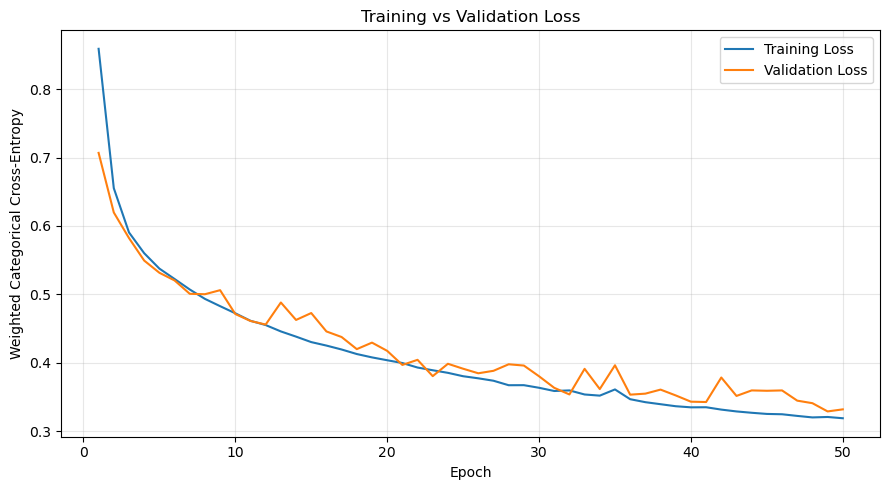

In [51]:
epochs = np.arange(1, history["epochs_trained"] + 1)

plt.figure(figsize=(9, 5))
plt.plot(epochs, history["train_loss"], label="Training Loss")
plt.plot(epochs, history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Weighted Categorical Cross-Entropy")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [53]:
test_probabilities = model.predict_proba(X_test)
y_pred = np.argmax(test_probabilities, axis=1)

print("Probability matrix shape:", test_probabilities.shape)
print("Predicted labels shape:", y_pred.shape)
print("First 5 probability rows:")
print(test_probabilities[:5])
print("\nProbability sums for first 5 samples:")
print(test_probabilities[:5].sum(axis=1))


Probability matrix shape: (58102, 7)
Predicted labels shape: (58102,)
First 5 probability rows:
[[8.92480016e-01 1.07515074e-01 9.87868554e-12 1.67336999e-28
  2.03166748e-13 3.96554667e-21 4.92745176e-06]
 [3.28144692e-02 8.82043898e-01 1.22628551e-13 6.90836599e-15
  8.51416960e-02 1.53224737e-13 8.24466160e-14]
 [1.75859760e-02 9.82414007e-01 8.03601968e-16 9.03837509e-43
  3.02297539e-25 6.52069789e-21 4.40898394e-11]
 [3.09604377e-01 6.90392971e-01 8.80510595e-11 1.65652378e-26
  2.03314796e-12 1.24404695e-10 2.63588117e-06]
 [7.55652960e-04 7.13039711e-02 1.67501941e-01 3.26355062e-02
  1.00840582e-03 7.26782441e-01 1.20632831e-05]]

Probability sums for first 5 samples:
[1.         1.         1.         1.         0.99999994]


In [55]:
accuracy = accuracy_score(y_test, y_pred)

precision_per_class = precision_score(
    y_test, y_pred, average=None, zero_division=0
)
recall_per_class = recall_score(
    y_test, y_pred, average=None, zero_division=0
)
f1_per_class = f1_score(
    y_test, y_pred, average=None, zero_division=0
)

macro_precision = precision_score(
    y_test, y_pred, average="macro", zero_division=0
)
macro_recall = recall_score(
    y_test, y_pred, average="macro", zero_division=0
)
macro_f1 = f1_score(
    y_test, y_pred, average="macro", zero_division=0
)

print(f"Test Accuracy       : {accuracy:.4f}")
print(f"Macro Precision     : {macro_precision:.4f}")
print(f"Macro Recall        : {macro_recall:.4f}")
print(f"Macro F1-score      : {macro_f1:.4f}")

metrics_table = pd.DataFrame({
    "Class": np.arange(1, K + 1),
    "Forest Cover Type": class_names,
    "Precision": precision_per_class,
    "Recall": recall_per_class,
    "F1-score": f1_per_class
})

display(metrics_table)


Test Accuracy       : 0.7990
Macro Precision     : 0.6641
Macro Recall        : 0.8788
Macro F1-score      : 0.7353


,Class,Forest Cover Type,Precision,Recall,F1-score
0,1,Spruce/Fir,0.809928,0.810234,0.810081
1,2,Lodgepole Pine,0.875207,0.766651,0.817340
2,3,Ponderosa Pine,0.810593,0.787472,0.798865
3,4,Cottonwood/Willow,0.538462,0.970803,0.692708
4,5,Aspen,0.382013,0.939937,0.543240
5,6,Douglas-fir,0.537298,0.899827,0.672837
6,7,Krummholz,0.695245,0.976597,0.812247


In [57]:
print(classification_report(
    y_test,
    y_pred,
    target_names=class_names,
    digits=4,
    zero_division=0
))


                   precision    recall  f1-score   support

       Spruce/Fir     0.8099    0.8102    0.8101     21184
   Lodgepole Pine     0.8752    0.7667    0.8173     28331
   Ponderosa Pine     0.8106    0.7875    0.7989      3576
Cottonwood/Willow     0.5385    0.9708    0.6927       274
            Aspen     0.3820    0.9399    0.5432       949
      Douglas-fir     0.5373    0.8998    0.6728      1737
        Krummholz     0.6952    0.9766    0.8122      2051

         accuracy                         0.7990     58102
        macro avg     0.6641    0.8788    0.7353     58102
     weighted avg     0.8213    0.7990    0.8040     58102



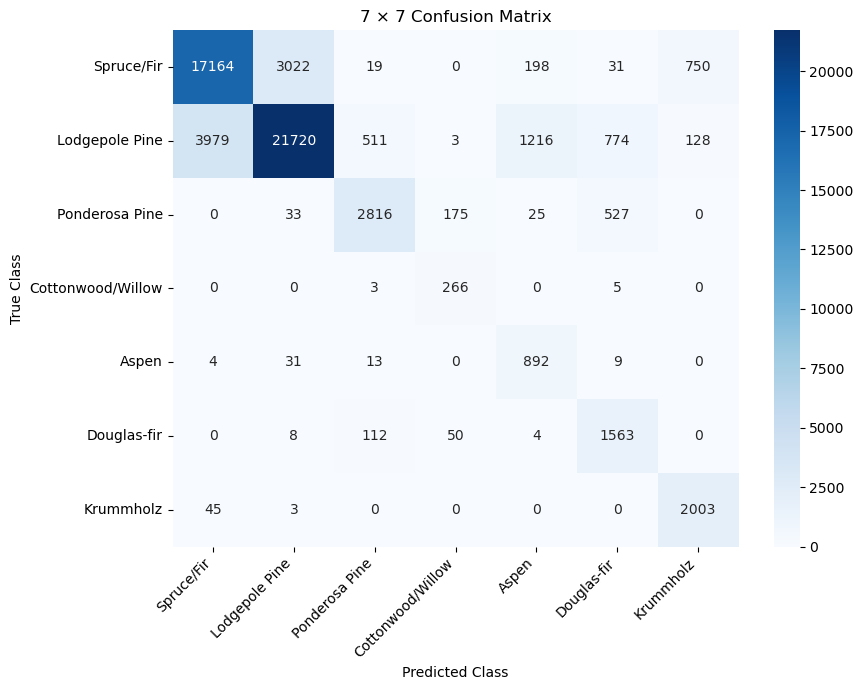

In [59]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(9, 7))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("7 × 7 Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


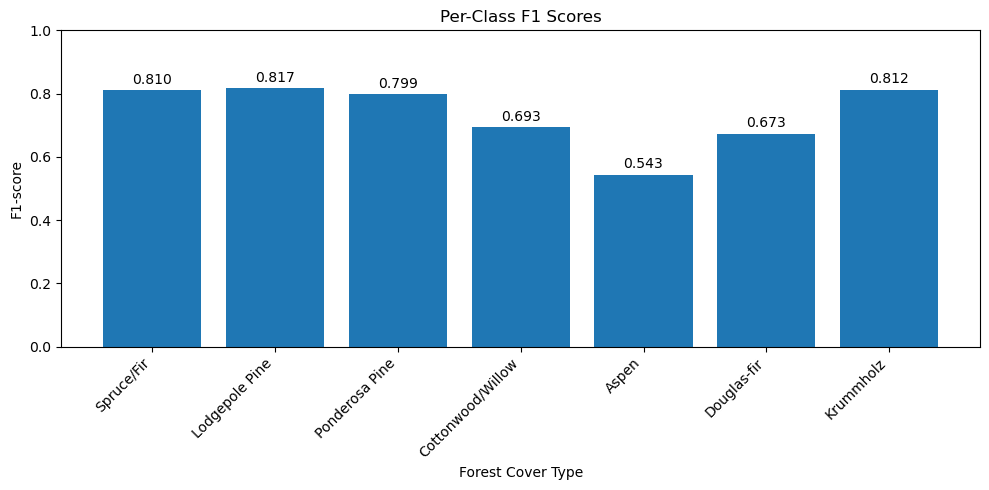

In [61]:
plt.figure(figsize=(10, 5))
bars = plt.bar(class_names, f1_per_class)
plt.xlabel("Forest Cover Type")
plt.ylabel("F1-score")
plt.title("Per-Class F1 Scores")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)

for bar, value in zip(bars, f1_per_class):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + 0.02,
        f"{value:.3f}",
        ha="center"
    )

plt.tight_layout()
plt.show()


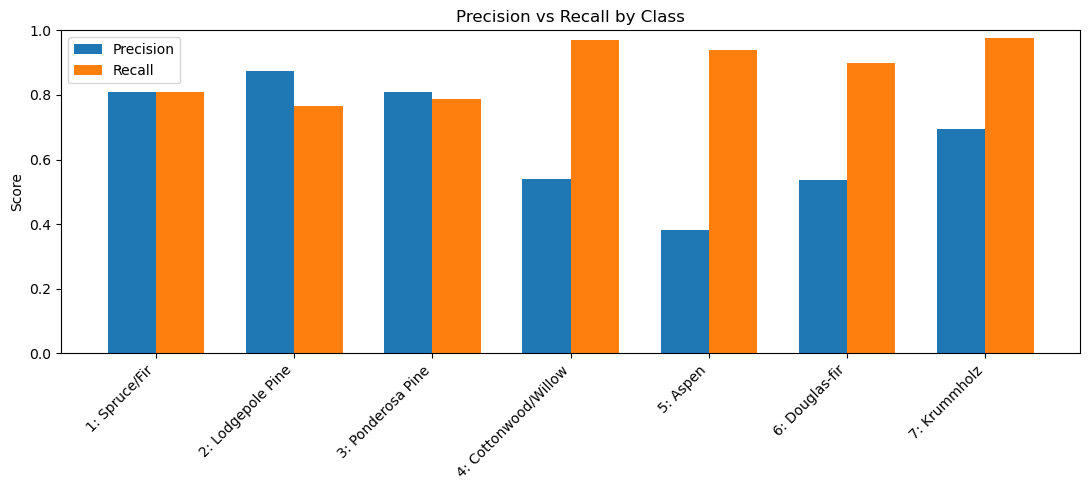

In [63]:
x = np.arange(K)
width = 0.35

plt.figure(figsize=(11, 5))
plt.bar(x - width/2, precision_per_class, width, label="Precision")
plt.bar(x + width/2, recall_per_class, width, label="Recall")

plt.xticks(x, [f"{i+1}: {name}" for i, name in enumerate(class_names)],
           rotation=45, ha="right")
plt.ylabel("Score")
plt.title("Precision vs Recall by Class")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()


,Class,Forest Cover Type,True Count,Predicted Count
0,1,Spruce/Fir,21184,21192
1,2,Lodgepole Pine,28331,24817
2,3,Ponderosa Pine,3576,3474
3,4,Cottonwood/Willow,274,494
4,5,Aspen,949,2335
5,6,Douglas-fir,1737,2909
6,7,Krummholz,2051,2881


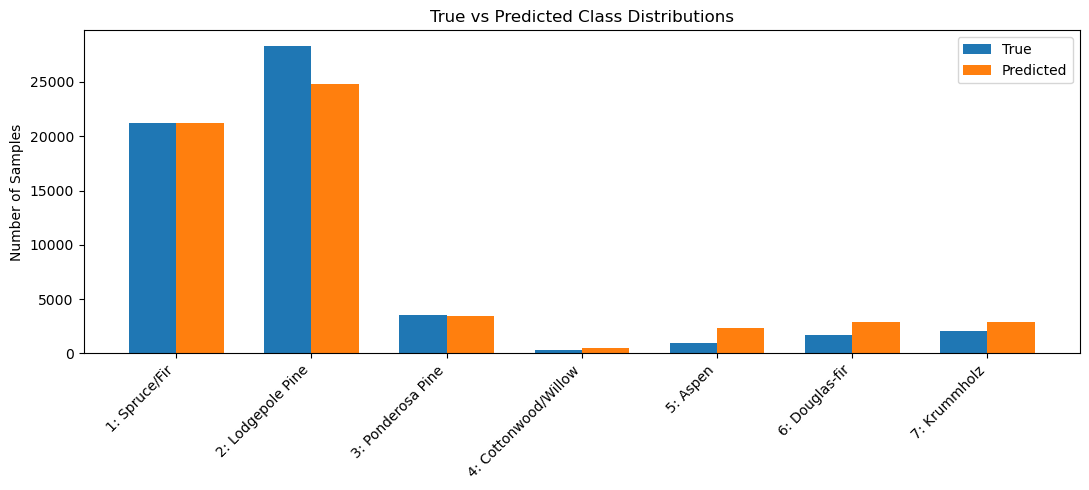

In [65]:
true_counts = np.bincount(y_test, minlength=K)
pred_counts = np.bincount(y_pred, minlength=K)

distribution_compare = pd.DataFrame({
    "Class": np.arange(1, K + 1),
    "Forest Cover Type": class_names,
    "True Count": true_counts,
    "Predicted Count": pred_counts
})

display(distribution_compare)

x = np.arange(K)
width = 0.35

plt.figure(figsize=(11, 5))
plt.bar(x - width/2, true_counts, width, label="True")
plt.bar(x + width/2, pred_counts, width, label="Predicted")

plt.xticks(x, [f"{i+1}: {name}" for i, name in enumerate(class_names)],
           rotation=45, ha="right")
plt.ylabel("Number of Samples")
plt.title("True vs Predicted Class Distributions")
plt.legend()
plt.tight_layout()
plt.show()


In [67]:
results_summary = pd.DataFrame({
    "Metric": [
        "Test Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1-score",
        "Epochs Trained",
        "Best Validation Loss"
    ],
    "Value": [
        accuracy,
        macro_precision,
        macro_recall,
        macro_f1,
        history["epochs_trained"],
        history["best_val_loss"]
    ]
})

display(results_summary)


,Metric,Value
0,Test Accuracy,0.799009
1,Macro Precision,0.664106
2,Macro Recall,0.878789
3,Macro F1-score,0.735331
4,Epochs Trained,50.000000
5,Best Validation Loss,0.329072


In [69]:
metrics_table.to_csv("per_class_metrics.csv", index=False)
distribution_compare.to_csv("true_vs_predicted_distribution.csv", index=False)
results_summary.to_csv("final_results_summary.csv", index=False)

print("Saved:")
print("- per_class_metrics.csv")
print("- true_vs_predicted_distribution.csv")
print("- final_results_summary.csv")


Saved:
- per_class_metrics.csv
- true_vs_predicted_distribution.csv
- final_results_summary.csv
